### 1. Importando pacotes

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from wordcloud import WordCloud

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from transformers import pipeline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\alice\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### 2. Carregamento dos dados

In [32]:

df = pd.read_csv('../data/tripadvisor_hotel_reviews.csv')

In [33]:

df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [34]:

df.shape

(20491, 2)

In [35]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  20491 non-null  str  
 1   Rating  20491 non-null  int64
dtypes: int64(1), str(1)
memory usage: 320.3 KB


### 3. Análise Exploratória (EDA)

Checar a distribuição das avaliações

In [36]:

df['Rating'].value_counts()

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64

- Dataset desbalanceado, com a maioria das avaliações sendo 5 estrelas.

Criar coluna sentimento no dataset

In [37]:
df['Sentiment'] = df['Rating'].map(lambda x: 'Positivo' if x >= 3 else 'Negativo')
df['Sentiment'].value_counts()

Sentiment
Positivo    17277
Negativo     3214
Name: count, dtype: int64

Porcentagem e visualização da distribuição dos sentimentos

In [38]:
porcentagem_sentimentos = df['Sentiment'].value_counts(normalize=True) * 100
porcentagem_sentimentos.head()

Sentiment
Positivo    84.315065
Negativo    15.684935
Name: proportion, dtype: float64

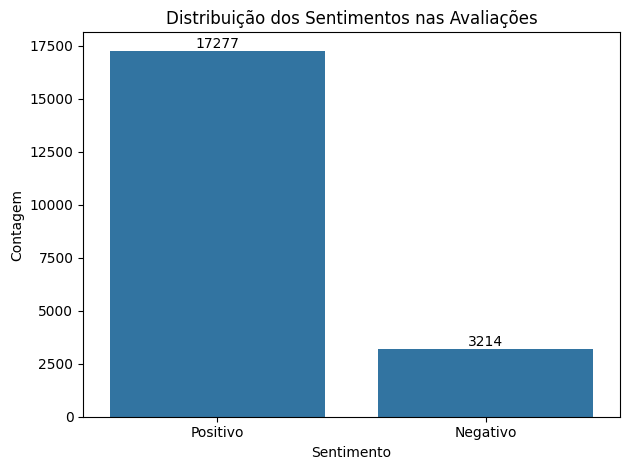

In [39]:

sns.countplot(x='Sentiment', data=df, order=['Positivo', 'Negativo'])

ax = plt.gca()
ax.bar_label(ax.containers[0])

plt.title('Distribuição dos Sentimentos nas Avaliações')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')

plt.tight_layout()
plt.savefig('../img/distribuicao_sentimentos.png')

plt.show()

O objetivo é descobrir se hóspedes insatisfeitos escrevem mais do que os satisfeitos
- É uma hipótese intuitiva: quem reclama tende a se explicar mais

In [40]:

df['review_length'] = df['Review'].str.split().str.len()
df.head()

,Review,Rating,Sentiment,review_length
0,nice hotel expensive parking got good deal sta...,4,Positivo,87
1,ok nothing special charge diamond member hilto...,2,Negativo,250
2,nice rooms not 4* experience hotel monaco seat...,3,Positivo,217
3,"unique, great stay, wonderful time hotel monac...",5,Positivo,89
4,"great stay great stay, went seahawk game aweso...",5,Positivo,191


In [41]:

words_sentiment = df.groupby('Sentiment')['review_length'].mean()
print(words_sentiment)

Sentiment
Negativo    120.307094
Positivo    101.412166
Name: review_length, dtype: float64



Resultado confirma hipótese:
- Hóspedes insatisfeitos escrevem mais
- Reviews negativas têm em média 120 palavras contra 101 das positivas

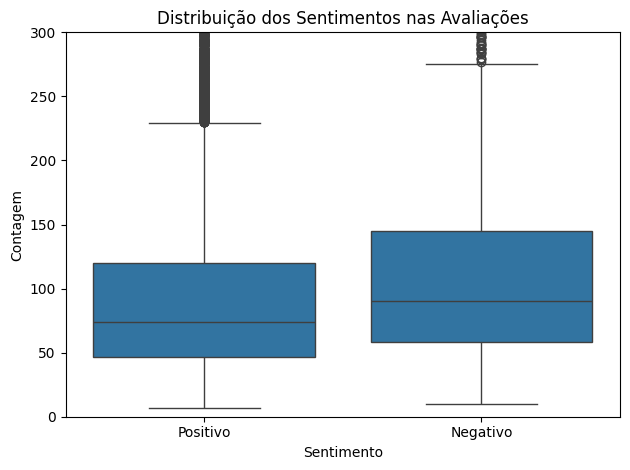

In [42]:

sns.boxplot(
    x='Sentiment',
    y= 'review_length',
    data=df
)

plt.ylim(0, 300)

plt.title('Distribuição dos Sentimentos nas Avaliações')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')

plt.tight_layout()
plt.savefig('../img/distribuicao_palavras.png')

plt.show()

- A maioria das reviews positivas fica entre ~50 e ~115 palavras 
- Negativas ficam entre ~60 e ~145
- Os pontos acima são outliers (algumas pessoas escreveram reviews gigantes independente do sentimento)

Visualizar palavras que aparecem nas reviews positivas e negativas:

In [43]:

df_positivos = df[df['Sentiment'] == 'Positivo']
texto_positivos = ' '.join(df_positivos['Review'])

Criar o objeto Wordcloud para palavras positivas:

In [44]:

# remover stopwords

remove_stopwords = set(stopwords.words('english'))

# remover palavras pouco úteis

remove_stopwords.update([
    'hotel', 'room', 'rooms', 'stay', 'stayed', 
    'one', 'would', 'could', 'also', 'like'
])

In [45]:
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords=remove_stopwords,
    colormap='viridis',
    max_words=100
).generate(texto_positivos)

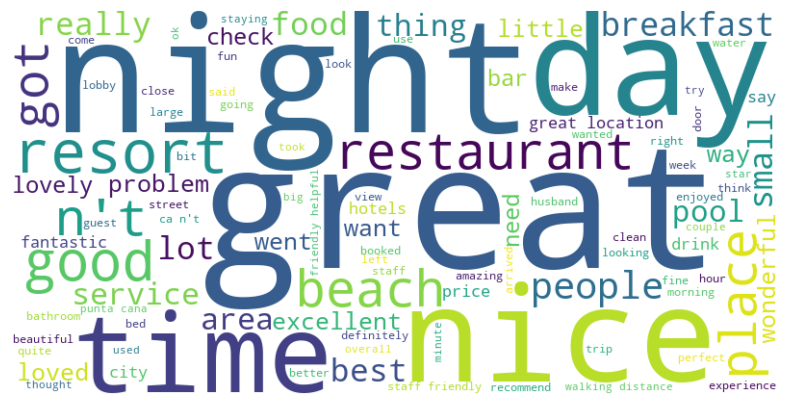

In [46]:

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.savefig('../img/nuvem_palavras_positivas.png')

plt.show()

In [47]:

df_negativos = df[df['Sentiment'] == 'Negativo']
texto_negativos = ' '.join(df_negativos['Review'])

Criar o objeto WordCloud para palavras negativas:

In [48]:
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords=remove_stopwords,
    colormap='viridis',
    max_words=100
).generate(texto_negativos)

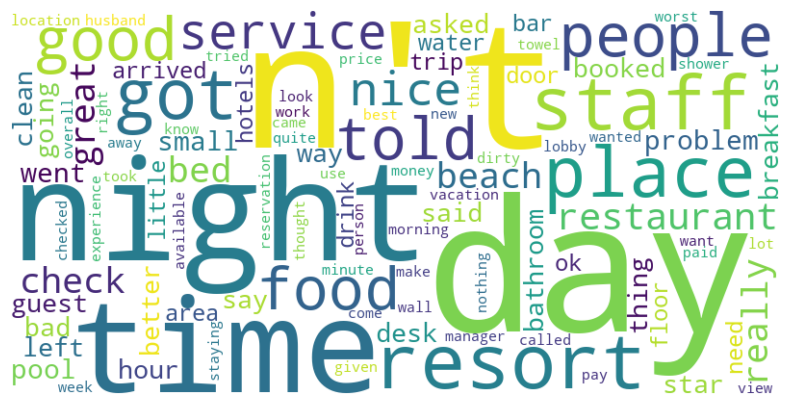

In [49]:

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.savefig('../img/nuvem_palavras_negativas.png')

plt.show()

- Reviews Positivas: O hóspede exalta a infraestrutura (pool, beach), o sabor (breakfast) e a hospitalidade (friendly)
- Reviews Negativas: O hóspede detalha possíveis falhas de processo (told, asked), falta de higiene (dirty) e quebra de sossego (noisy)

### 4. Pré-processamento do texto

In [50]:

# restaurar stopwords para ML

stopwords_ml = set(stopwords.words('english'))

# manter negação 
stopwords_ml = stopwords_ml - {"not", "no", "nor"}

Pipeline de pré-processamento:

In [51]:

lemmatizer = WordNetLemmatizer()

def preprocess(text):

    # 1. lowercase
    text = text.lower()
    
    # 2. remove pontuação com re.sub()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. tokenização
    words = word_tokenize(text)
    
    # 4. remove stopwords
    words = [word for word in words if word not in stopwords_ml]
    
    # 5. lemmatização de cada token
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # 6. juntar tudo de volta
    texto_limpo = ' '.join(words)
    
    return texto_limpo

In [52]:

df['Review_Clean'] = df['Review'].apply(preprocess)
df[['Review', 'Review_Clean']].head()

,Review,Review_Clean
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


### 5. Vetorizar e treinar o modelo

In [53]:

X = df['Review_Clean']
y = df['Sentiment']

In [54]:

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42
)

In [55]:

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

Fit apenas no treino para evitar data leakage:

In [56]:

X_train_tfidf = vectorizer.fit_transform(X_train)

In [57]:

X_test_tfidf = vectorizer.transform(X_test)

#### Treinar o modelo de Regressão Logística

- A amostra está muito desbalanceada, tratamos o desbalanceamento

In [58]:

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [59]:
y_pred = model.predict(X_test_tfidf)

Vamos avaliar o modelo de regressão logistica:

In [60]:

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9258355696511344


In [61]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.69      0.92      0.79       625
    Positivo       0.99      0.93      0.95      3474

    accuracy                           0.93      4099
   macro avg       0.84      0.93      0.87      4099
weighted avg       0.94      0.93      0.93      4099



- Modelo atinge *93% de acurácia*, com excelente desempenho na classe positiva e alto recall para negativos.
- Importante para capturar avaliações insatisfeitas

Vamos fazer o teste do mesmo modelo de Regressão Logística sem balanceamento:

In [62]:
model_unbalanced = LogisticRegression()
model_unbalanced.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [63]:
y_pred = model_unbalanced.predict(X_test_tfidf)

In [64]:

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9385215906318615


In [65]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.88      0.69      0.77       625
    Positivo       0.95      0.98      0.96      3474

    accuracy                           0.94      4099
   macro avg       0.92      0.84      0.87      4099
weighted avg       0.94      0.94      0.94      4099



- Modelo se balanceamento obteve maior acurácia (94%), mas com perda significativa de recall para a classe negativa.
- Com base no objetivo do negócio, maximizar o recall da classe negativa é mais importante do que a acurácia geral, já que perder avaliações negativas significaria ignorar potenciais problemas operacionais. 
- Dessa forma, optei por utilizar o modelo com class_weight='balanced'

### 6. Comparar abordagens léxico-baseada x supervisionada

In [66]:
sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

df['vader_sentiment'] = df['vader_score'].apply(
    lambda x: 'Positivo' if x >= 0 else 'Negativo'
)

In [67]:

print(classification_report(df['Sentiment'], df['vader_sentiment']))

              precision    recall  f1-score   support

    Negativo       0.83      0.42      0.55      3214
    Positivo       0.90      0.98      0.94     17277

    accuracy                           0.89     20491
   macro avg       0.86      0.70      0.75     20491
weighted avg       0.89      0.89      0.88     20491



- Apesar de uma boa acurácia geral (89%), o modelo apresenta baixo recall para a classe negativa, falhando em identificar a maioria das avaliações insatisfeitas, o que compromete seu uso em cenários de monitoramento de qualidade

### 7. Testar outros modelos clássicos de ML

#### Naive Bayes

In [71]:

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [72]:

y_pred = nb.predict(X_test_tfidf)

Avaliar o modelo naive bayes

In [73]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.87      0.59      0.70       625
    Positivo       0.93      0.98      0.96      3474

    accuracy                           0.92      4099
   macro avg       0.90      0.79      0.83      4099
weighted avg       0.92      0.92      0.92      4099



- O modelo Naive Bayes apresentou boa precisão para a classe negativa (87%), indicando baixo número de falsos positivos. No entanto, seu recall foi limitado (59%), evidenciando dificuldade em identificar uma parcela significativa das avaliações insatisfeitas.

#### SVM

In [74]:

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [75]:

y_pred = svm.predict(X_test_tfidf)

Avaliar o modelo SVM

In [76]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.82      0.76      0.79       625
    Positivo       0.96      0.97      0.96      3474

    accuracy                           0.94      4099
   macro avg       0.89      0.87      0.88      4099
weighted avg       0.94      0.94      0.94      4099



- O modelo SVM apresentou desempenho equilibrado, com 82% de precisão e 76% de recall para a classe negativa, conseguindo identificar boa parte das avaliações insatisfeitas sem gerar muitos falsos positivos.

### 8. Testar BERT pré-treinado

In [77]:

# criar pipeline
model = pipeline("sentiment-analysis")

# aplicar no dataset (retorna label e score)
def get_label(text):
    result = model(text, truncation=True)[0]
    # mapear para o padrão do dataset
    return "Negativo" if result['label'] == 'NEGATIVE' else "Positivo"

# criar coluna com previsão do BERT
df['bert_sentiment'] = df['Review'].apply(get_label)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3780.06it/s]


In [78]:
print(classification_report(df['Sentiment'], df['bert_sentiment']))
print(accuracy_score(df['Sentiment'], df['bert_sentiment']))

              precision    recall  f1-score   support

    Negativo       0.44      0.93      0.60      3214
    Positivo       0.98      0.78      0.87     17277

    accuracy                           0.80     20491
   macro avg       0.71      0.86      0.73     20491
weighted avg       0.90      0.80      0.83     20491

0.8043043287296862


- O modelo baseado em transformer (DistilBERT) apresentou o maior recall para a classe negativa (93%), demonstrando alta capacidade de identificar avaliações insatisfeitas. No entanto, apresentou baixa precisão (44%), indicando elevado número de falsos positivos. 

- Em cenários onde é crítico não perder clientes insatisfeitos, o uso de modelos baseados em transformers é recomendado. Entretanto, para operações que exigem maior eficiência e menor volume de alertas falsos, modelos como Regressão Logística podem oferecer melhor equilíbrio

Visualizando e comparando o valor do recall dos modelos:

In [79]:

recall_neg = {
    'VADER': 0.42,
    'Logistic Balanced': 0.92,
    'Logistic Unbalanced': 0.69,  
    'Naive Bayes': 0.59,
    'SVM': 0.76,
    'BERT': 0.93
}

In [80]:

# nomes dos modelos
modelos = list(recall_neg.keys())

# valores de recall
valores = list(recall_neg.values())

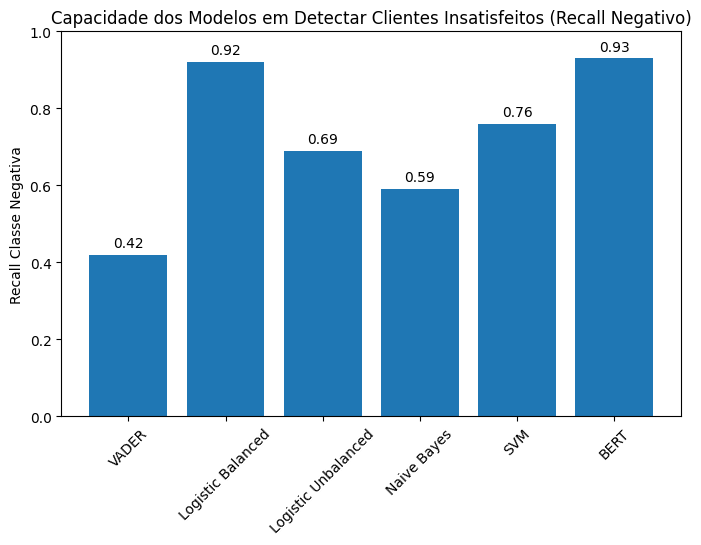

In [81]:

plt.figure(figsize=(8,5))
plt.bar(modelos, valores)
plt.ylim(0, 1)
plt.ylabel('Recall Classe Negativa')
plt.title('Capacidade dos Modelos em Detectar Clientes Insatisfeitos (Recall Negativo)')
plt.xticks(rotation=45)

for i, v in enumerate(valores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.savefig('../img/comparacao_recall_modelos.png')

plt.show()

#### Conclusão da comparação:
- Para o objetivo da HospedaAI, a Regressão Logística Balanceada continua sendo a melhor escolha, mesmo recall que o BERT, mas com precision muito superior. Além de ter sido treinada nos próprios dados do problema.